# Complete Control Systems Guide: Test Signals, Time Response, and Frequency Analysis

This notebook covers the fundamental concepts of control systems analysis, including test signals, time response parameters, and frequency domain analysis.

## Table of Contents
1. [Test Signals](#test-signals)
2. [Steady State Error](#steady-state-error)
3. [System Order and Type](#system-order-and-type)
4. [Time Response Analysis](#time-response-analysis)
5. [Time Response Parameters](#time-response-parameters)
6. [Frequency Response Analysis](#frequency-response-analysis)
7. [Practical Examples](#practical-examples)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import control as ct
from matplotlib.patches import Rectangle

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.style.use('seaborn-v0_8')

## 1. Test Signals

Test signals are essential for analyzing and evaluating control systems. They help in system characterization and performance evaluation.

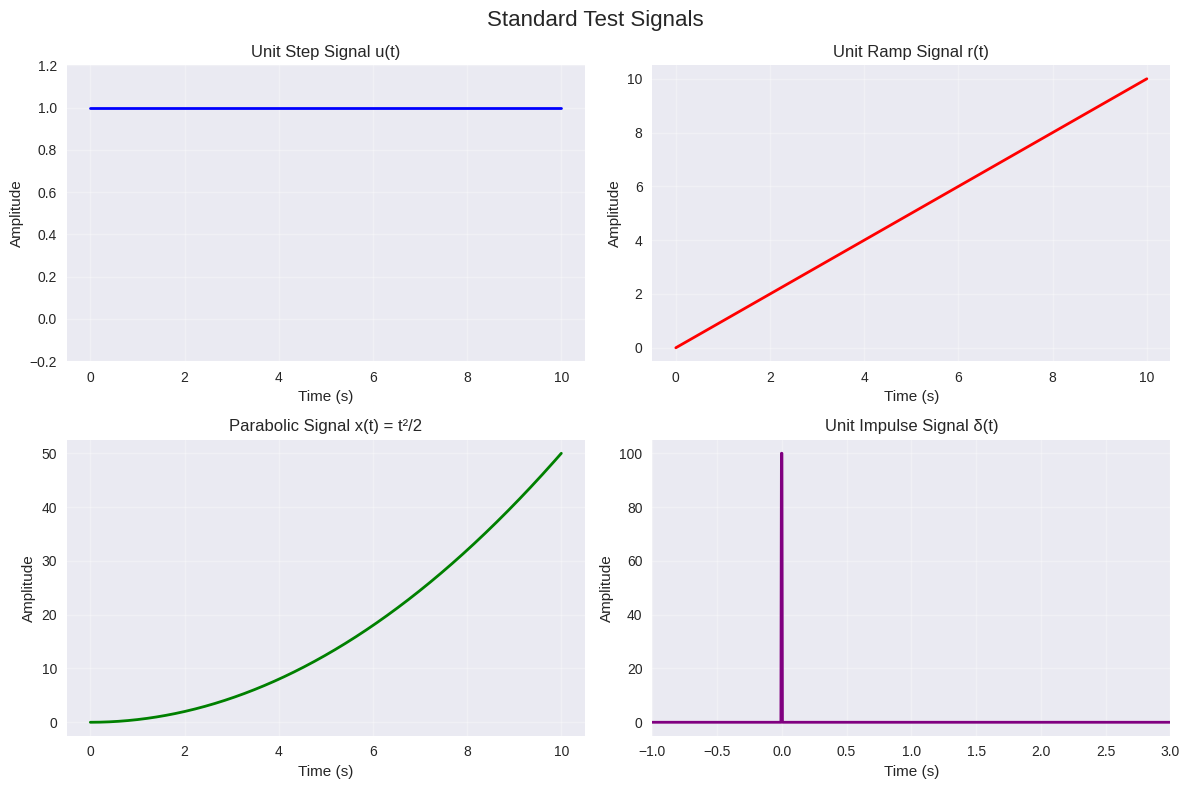

Laplace Transforms of Test Signals:
δ(t) ↔ 1
u(t) ↔ 1/s
r(t) ↔ 1/s²
x(t) ↔ 1/s³


In [21]:
# Generate time vector
t = np.linspace(0, 10, 1000)

# Define test signals
def unit_step(t):
    return np.heaviside(t, 1)

def unit_ramp(t):
    return t * (t >= 0)

def parabolic(t):
    return 0.5 * t**2 * (t >= 0)

def unit_impulse(t, dt=0.01):
    impulse = np.zeros_like(t)
    impulse[np.abs(t) < dt/2] = 1/dt
    return impulse

# Plot test signals
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Standard Test Signals', fontsize=16)

# Unit Step
axes[0, 0].plot(t, unit_step(t), 'b-', linewidth=2)
axes[0, 0].set_title('Unit Step Signal u(t)')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(-0.2, 1.2)

# Unit Ramp
axes[0, 1].plot(t, unit_ramp(t), 'r-', linewidth=2)
axes[0, 1].set_title('Unit Ramp Signal r(t)')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True, alpha=0.3)

# Parabolic
axes[1, 0].plot(t, parabolic(t), 'g-', linewidth=2)
axes[1, 0].set_title('Parabolic Signal x(t) = t²/2')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].grid(True, alpha=0.3)

# Unit Impulse (approximation)
t_impulse = np.linspace(-1, 3, 1000)
axes[1, 1].plot(t_impulse, unit_impulse(t_impulse), 'purple', linewidth=2)
axes[1, 1].set_title('Unit Impulse Signal δ(t)')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(-1, 3)

plt.tight_layout()
plt.show()

# Display Laplace transforms
print("Laplace Transforms of Test Signals:")
print("δ(t) ↔ 1")
print("u(t) ↔ 1/s")
print("r(t) ↔ 1/s²")
print("x(t) ↔ 1/s³")

## 2. Steady State Error Analysis

Steady state error is the error when time t approaches infinity. It determines the accuracy of the system.

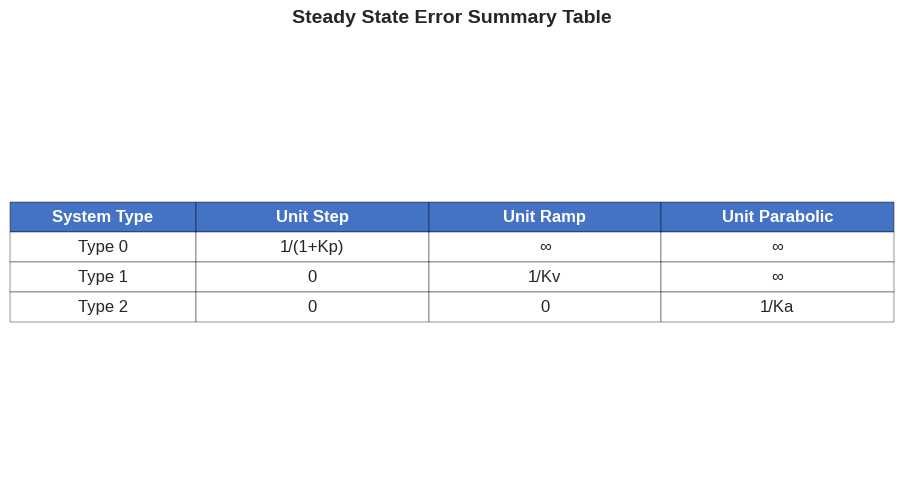

Static Error Constants:
Kp (Position) = lim(s→0) G(s)H(s)
Kv (Velocity) = lim(s→0) s·G(s)H(s)
Ka (Acceleration) = lim(s→0) s²·G(s)H(s)


In [11]:
def steady_state_error_analysis():
    """Analyze steady state error for different system types and inputs"""
    
    # Define system types
    inputs = ['Unit Step', 'Unit Ramp', 'Unit Parabolic']
    system_types = ['Type 0', 'Type 1', 'Type 2']
    
    # Steady state errors
    errors = {
        'Type 0': ['1/(1+Kp)', '∞', '∞'],
        'Type 1': ['0', '1/Kv', '∞'],
        'Type 2': ['0', '0', '1/Ka']
    }
    
    # Create table
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('tight')
    ax.axis('off')
    
    # Create table data
    table_data = []
    table_data.append(['System Type'] + inputs)
    for sys_type in system_types:
        table_data.append([sys_type] + errors[sys_type])
    
    table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                    colWidths=[0.2, 0.25, 0.25, 0.25])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.8)
    
    # Style the header row
    for i in range(4):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    plt.title('Steady State Error Summary Table', fontsize=14, fontweight='bold')
    plt.show()
    
    # Error constants
    print("Static Error Constants:")
    print("Kp (Position) = lim(s→0) G(s)H(s)")
    print("Kv (Velocity) = lim(s→0) s·G(s)H(s)")
    print("Ka (Acceleration) = lim(s→0) s²·G(s)H(s)")

steady_state_error_analysis()

## 3. System Order and Type Analysis

In [12]:
def analyze_transfer_function(num, den):
    """Analyze transfer function to determine order and type"""
    
    # Create transfer function
    sys = ct.tf(num, den)
    
    # Find poles and zeros
    poles = ct.poles(sys)
    zeros = ct.zero(sys)
    
    # Determine order (number of poles)
    order = len(poles)
    
    # Determine type (number of poles at origin)
    poles_at_origin = np.sum(np.abs(poles) < 1e-10)
    system_type = poles_at_origin
    
    print(f"Transfer Function: {sys}")
    print(f"Poles: {poles}")
    print(f"Zeros: {zeros}")
    print(f"System Order: {order}")
    print(f"System Type: {system_type}")
    print("-" * 50)
    
    return sys, order, system_type

# Example 1: T(s) = k/(s² + s)
print("Example 1: T(s) = 10/(s² + s)")
sys1, order1, type1 = analyze_transfer_function([10], [1, 1, 0])

# Example 2: T(s) = k(s + 2)/(s² + 3s + 2)
print("Example 2: T(s) = 5(s + 2)/(s² + 3s + 2)")
sys2, order2, type2 = analyze_transfer_function([5, 10], [1, 3, 2])

# Example 3: T(s) = k(s + 1)(s + 6)/(s³ + 4s² + 3s)
print("Example 3: T(s) = 2(s + 1)(s + 6)/(s³ + 4s² + 3s)")
# Expanded: 2(s² + 7s + 6)/(s³ + 4s² + 3s)
sys3, order3, type3 = analyze_transfer_function([2, 14, 12], [1, 4, 3, 0])

Example 1: T(s) = 10/(s² + s)


AttributeError: module 'control' has no attribute 'zero'

## 4. Time Response Analysis

### First Order System Response

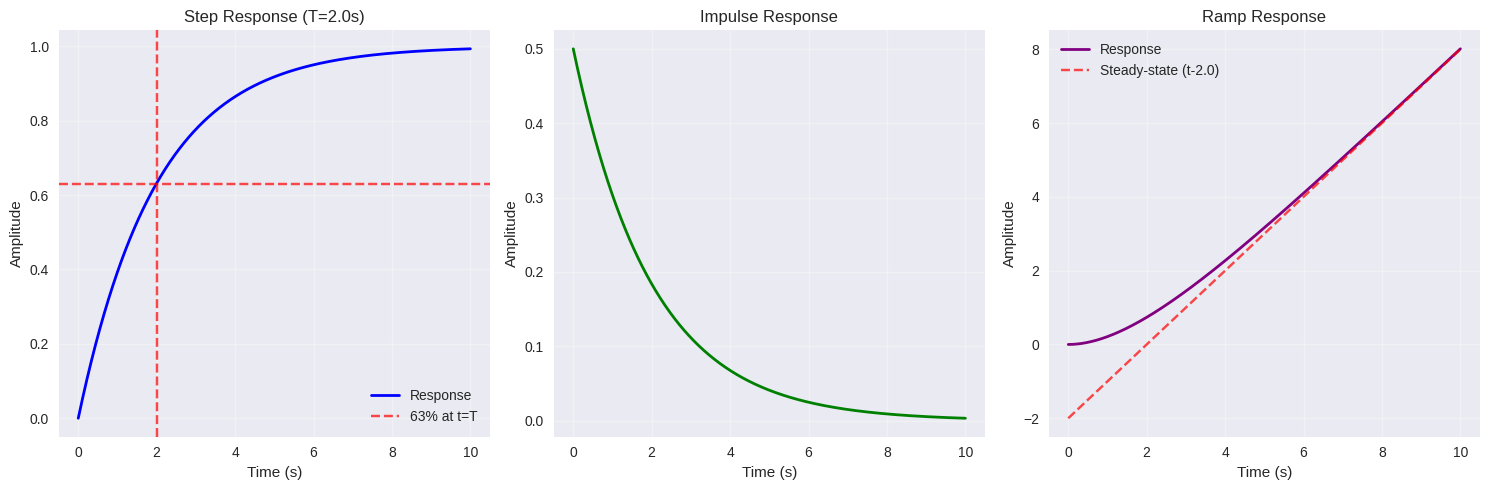

First Order System Analysis (T = 2.0s):
At t = T: Response = 0.632 (63% of final value)
At t = 2T: Response = 0.865 (86% of final value)
At t = 3T: Response = 0.950 (95% of final value)
Steady-state error for ramp input: 2.0


In [13]:
def first_order_response():
    """Analyze first order system responses"""
    
    # Time constant
    T = 2.0  # seconds
    
    # Transfer function: 1/(1 + sT)
    sys = ct.tf([1], [T, 1])
    
    # Time vector
    t = np.linspace(0, 10, 1000)
    
    # Step response
    t_step, y_step = ct.step_response(sys, t)
    
    # Impulse response  
    t_impulse, y_impulse = ct.impulse_response(sys, t)
    
    # Ramp response (integrator * step response)
    ramp_sys = ct.tf([1], [T, 1, 0])  # Add integrator
    t_ramp, y_ramp = ct.step_response(ramp_sys, t)
    
    # Plot responses
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Step response
    axes[0].plot(t_step, y_step, 'b-', linewidth=2, label='Response')
    axes[0].axhline(y=0.63, color='r', linestyle='--', alpha=0.7, label='63% at t=T')
    axes[0].axvline(x=T, color='r', linestyle='--', alpha=0.7)
    axes[0].set_title(f'Step Response (T={T}s)')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Impulse response
    axes[1].plot(t_impulse, y_impulse, 'g-', linewidth=2)
    axes[1].set_title('Impulse Response')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Amplitude')
    axes[1].grid(True, alpha=0.3)
    
    # Ramp response
    axes[2].plot(t_ramp, y_ramp, 'purple', linewidth=2, label='Response')
    axes[2].plot(t, t - T, 'r--', alpha=0.7, label=f'Steady-state (t-{T})')
    axes[2].set_title('Ramp Response')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Amplitude')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"First Order System Analysis (T = {T}s):")
    print(f"At t = T: Response = {1 - np.exp(-1):.3f} (63% of final value)")
    print(f"At t = 2T: Response = {1 - np.exp(-2):.3f} (86% of final value)")
    print(f"At t = 3T: Response = {1 - np.exp(-3):.3f} (95% of final value)")
    print(f"Steady-state error for ramp input: {T}")

first_order_response()

### Second Order System Response

/home/spensermillburn/.local/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


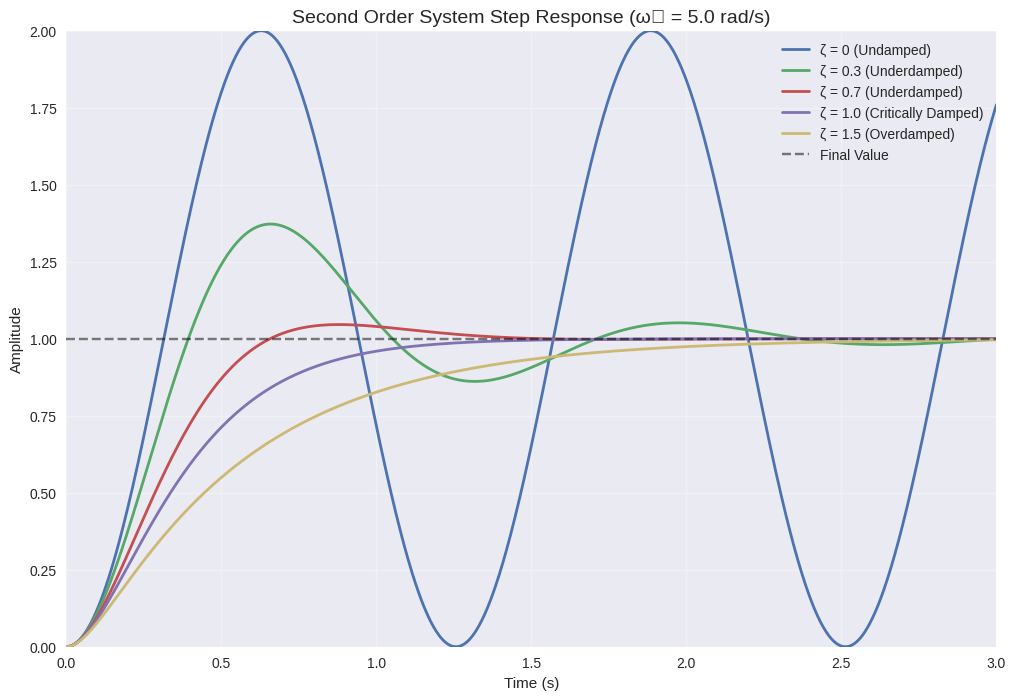


For underdamped case (ζ = 0.3):
Natural frequency: ωₙ = 5.0 rad/s
Damped frequency: ωd = 4.77 rad/s
Real part of poles: σ = 1.50
Poles: s₁,₂ = -1.50 ± j4.77


In [14]:
def second_order_response():
    """Analyze second order system responses for different damping ratios"""
    
    # System parameters
    wn = 5.0  # Natural frequency
    zeta_values = [0, 0.3, 0.7, 1.0, 1.5]  # Different damping ratios
    labels = ['Undamped', 'Underdamped', 'Underdamped', 'Critically Damped', 'Overdamped']
    
    # Time vector
    t = np.linspace(0, 3, 1000)
    
    plt.figure(figsize=(12, 8))
    
    for i, zeta in enumerate(zeta_values):
        # Transfer function: wn²/(s² + 2*zeta*wn*s + wn²)
        sys = ct.tf([wn**2], [1, 2*zeta*wn, wn**2])
        
        # Step response
        t_resp, y_resp = ct.step_response(sys, t)
        
        plt.plot(t_resp, y_resp, linewidth=2, label=f'ζ = {zeta} ({labels[i]})')
    
    plt.axhline(y=1, color='k', linestyle='--', alpha=0.5, label='Final Value')
    plt.title(f'Second Order System Step Response (ωₙ = {wn} rad/s)', fontsize=14)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xlim(0, 3)
    plt.ylim(0, 2)
    plt.show()
    
    # Pole locations for underdamped case
    zeta_demo = 0.3
    wd = wn * np.sqrt(1 - zeta_demo**2)
    sigma = zeta_demo * wn
    
    print(f"\nFor underdamped case (ζ = {zeta_demo}):")
    print(f"Natural frequency: ωₙ = {wn} rad/s")
    print(f"Damped frequency: ωd = {wd:.2f} rad/s")
    print(f"Real part of poles: σ = {sigma:.2f}")
    print(f"Poles: s₁,₂ = -{sigma:.2f} ± j{wd:.2f}")

second_order_response()

## 5. Time Response Parameters for Second Order Systems

/tmp/ipykernel_174967/2737947195.py:76: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Liberation Sans.
  plt.tight_layout()


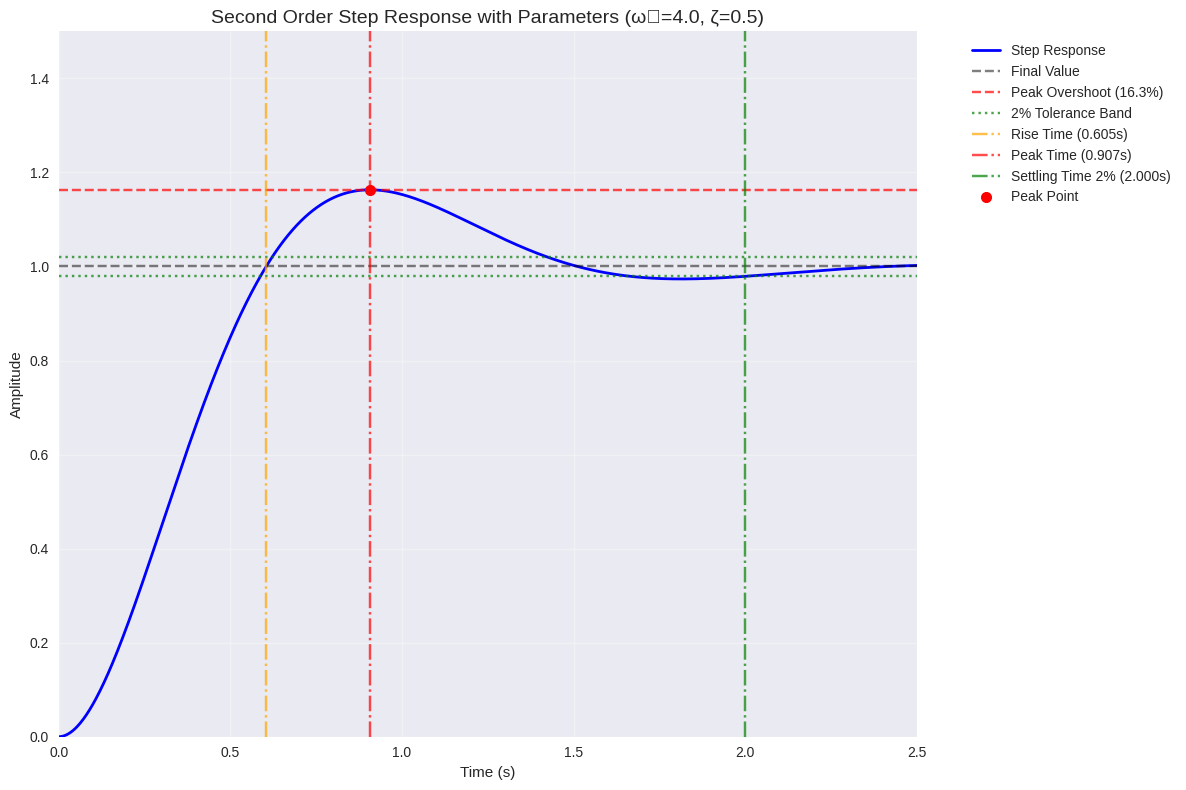

Time Response Parameters (ωₙ = 4.0 rad/s, ζ = 0.5):
Damped frequency: ωd = 3.464 rad/s
Rise time: Tr = 0.605 s
Peak time: Tp = 0.907 s
Peak overshoot: Mp = 0.163 (16.3%)
Settling time (2%): Ts = 2.000 s
Settling time (5%): Ts = 1.500 s


In [15]:
def calculate_time_response_parameters(wn, zeta):
    """Calculate time response parameters for second order system"""
    
    if zeta >= 1:
        print(f"System is overdamped (ζ = {zeta}), no oscillatory response")
        return None
    
    # Calculate parameters
    wd = wn * np.sqrt(1 - zeta**2)  # Damped frequency
    theta = np.arctan(np.sqrt(1 - zeta**2) / zeta)  # Phase angle
    
    # Time response parameters
    tr = (np.pi - theta) / wd  # Rise time
    tp = np.pi / wd  # Peak time
    mp = np.exp(-zeta * np.pi / np.sqrt(1 - zeta**2))  # Peak overshoot
    ts_2 = 4 / (zeta * wn)  # Settling time (2%)
    ts_5 = 3 / (zeta * wn)  # Settling time (5%)
    
    return {
        'wd': wd,
        'theta': theta,
        'tr': tr,
        'tp': tp,
        'mp': mp,
        'mp_percent': mp * 100,
        'ts_2': ts_2,
        'ts_5': ts_5
    }

def plot_time_response_parameters():
    """Plot step response with time response parameters marked"""
    
    # System parameters
    wn = 4.0
    zeta = 0.5
    
    # Calculate parameters
    params = calculate_time_response_parameters(wn, zeta)
    
    if params is None:
        return
    
    # Transfer function
    sys = ct.tf([wn**2], [1, 2*zeta*wn, wn**2])
    
    # Time vector
    t = np.linspace(0, 3, 1000)
    
    # Step response
    t_resp, y_resp = ct.step_response(sys, t)
    
    plt.figure(figsize=(12, 8))
    plt.plot(t_resp, y_resp, 'b-', linewidth=2, label='Step Response')
    
    # Mark important points and lines
    plt.axhline(y=1, color='k', linestyle='--', alpha=0.5, label='Final Value')
    plt.axhline(y=1 + params['mp'], color='r', linestyle='--', alpha=0.7, label=f'Peak Overshoot ({params["mp_percent"]:.1f}%)')
    plt.axhline(y=1.02, color='g', linestyle=':', alpha=0.7, label='2% Tolerance Band')
    plt.axhline(y=0.98, color='g', linestyle=':', alpha=0.7)
    
    # Vertical lines for time parameters
    plt.axvline(x=params['tr'], color='orange', linestyle='-.', alpha=0.7, label=f'Rise Time ({params["tr"]:.3f}s)')
    plt.axvline(x=params['tp'], color='r', linestyle='-.', alpha=0.7, label=f'Peak Time ({params["tp"]:.3f}s)')
    plt.axvline(x=params['ts_2'], color='g', linestyle='-.', alpha=0.7, label=f'Settling Time 2% ({params["ts_2"]:.3f}s)')
    
    # Mark specific points
    plt.plot(params['tp'], 1 + params['mp'], 'ro', markersize=8, label='Peak Point')
    
    plt.title(f'Second Order Step Response with Parameters (ωₙ={wn}, ζ={zeta})', fontsize=14)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 2.5)
    plt.ylim(0, 1.5)
    plt.tight_layout()
    plt.show()
    
    # Print parameters
    print(f"Time Response Parameters (ωₙ = {wn} rad/s, ζ = {zeta}):")
    print(f"Damped frequency: ωd = {params['wd']:.3f} rad/s")
    print(f"Rise time: Tr = {params['tr']:.3f} s")
    print(f"Peak time: Tp = {params['tp']:.3f} s")
    print(f"Peak overshoot: Mp = {params['mp']:.3f} ({params['mp_percent']:.1f}%)")
    print(f"Settling time (2%): Ts = {params['ts_2']:.3f} s")
    print(f"Settling time (5%): Ts = {params['ts_5']:.3f} s")

plot_time_response_parameters()

## 6. Frequency Response Analysis

/home/spensermillburn/.local/lib/python3.13/site-packages/control/lti.py:524: FutureWarning: freqresp() is deprecated; use frequency_response()
  warn("freqresp() is deprecated; use frequency_response()", FutureWarning)
/tmp/ipykernel_174967/1101527419.py:91: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Liberation Sans.
  plt.tight_layout()


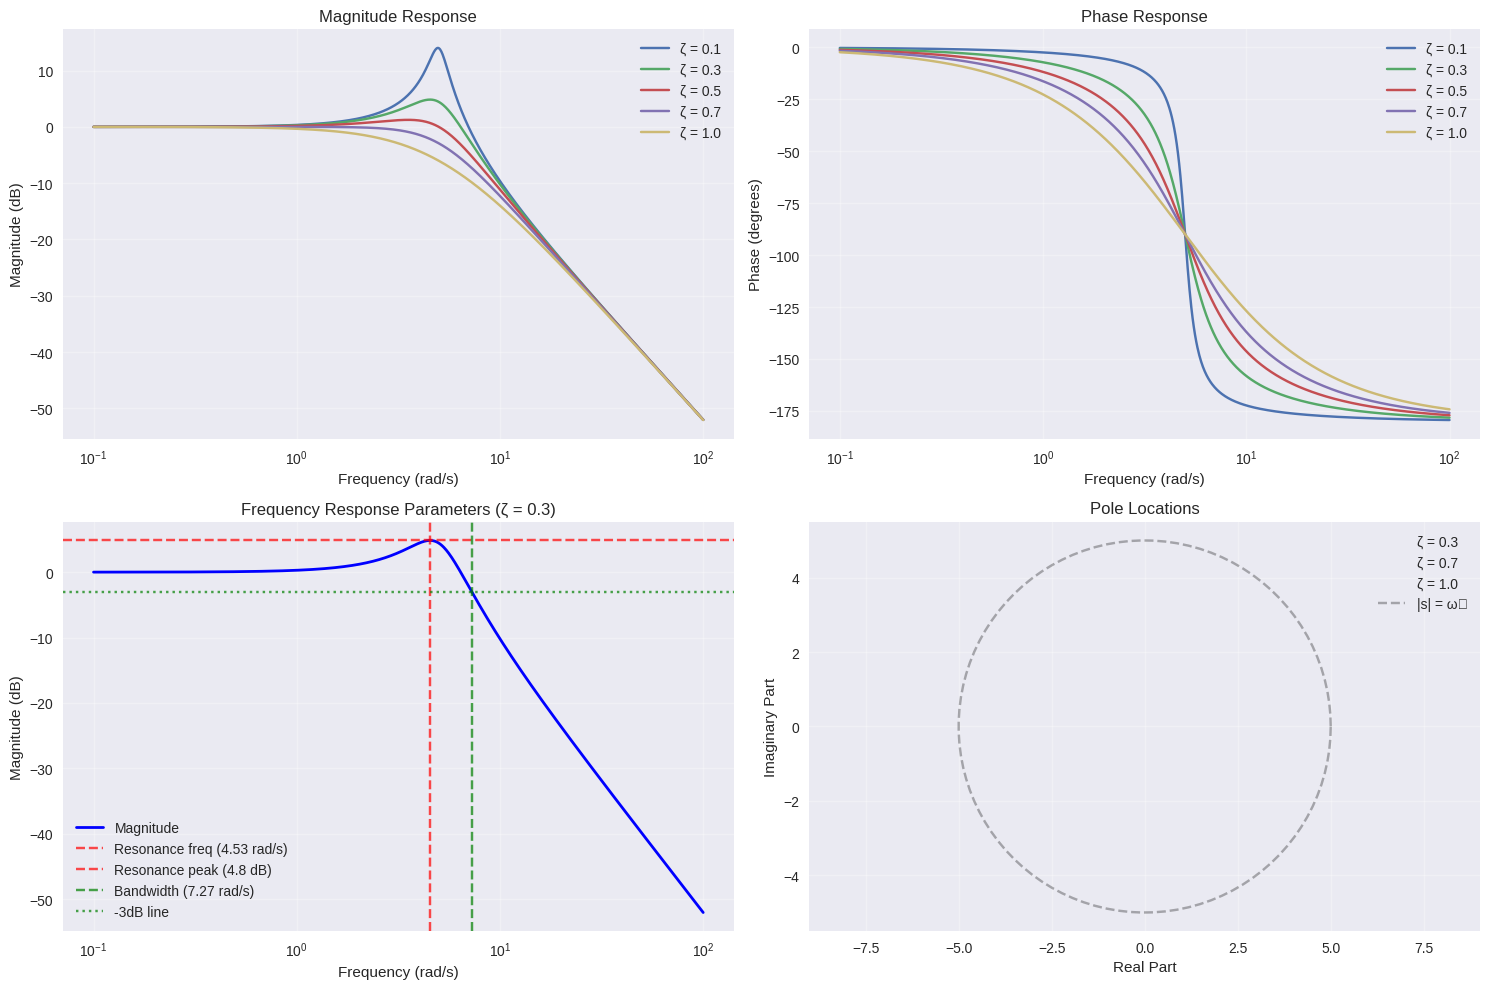

Frequency Response Parameters (ωₙ = 5.0 rad/s, ζ = 1.0):
Resonance frequency: ωᵣ = 4.528 rad/s
Resonance peak: Mᵣ = 1.747 (4.8 dB)
Bandwidth: ωb = 7.268 rad/s


In [16]:
def frequency_response_analysis():
    """Analyze frequency response of second order systems"""
    
    # System parameters
    wn = 5.0
    zeta_values = [0.1, 0.3, 0.5, 0.7, 1.0]
    
    # Frequency vector
    w = np.logspace(-1, 2, 1000)
    
    plt.figure(figsize=(15, 10))
    
    # Magnitude plot
    plt.subplot(2, 2, 1)
    for zeta in zeta_values:
        sys = ct.tf([wn**2], [1, 2*zeta*wn, wn**2])
        mag, phase, omega = ct.freqresp(sys, w)
        plt.semilogx(omega, 20 * np.log10(np.abs(mag)), label=f'ζ = {zeta}')
    
    plt.title('Magnitude Response')
    plt.xlabel('Frequency (rad/s)')
    plt.ylabel('Magnitude (dB)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Phase plot
    plt.subplot(2, 2, 2)
    for zeta in zeta_values:
        sys = ct.tf([wn**2], [1, 2*zeta*wn, wn**2])
        mag, phase, omega = ct.freqresp(sys, w)
        plt.semilogx(omega, np.degrees(phase), label=f'ζ = {zeta}')
    
    plt.title('Phase Response')
    plt.xlabel('Frequency (rad/s)')
    plt.ylabel('Phase (degrees)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Calculate frequency response parameters for specific case
    zeta = 0.3
    
    # Resonance frequency (exists only if zeta < 1/sqrt(2))
    if zeta < 1/np.sqrt(2):
        wr = wn * np.sqrt(1 - 2*zeta**2)
        Mr = 1 / (2 * zeta * np.sqrt(1 - zeta**2))
    else:
        wr = 0
        Mr = 1
    
    # Bandwidth (approximate)
    wb = wn * np.sqrt((1 - 2*zeta**2) + np.sqrt(4*zeta**4 - 4*zeta**2 + 2))
    
    # Plot resonance characteristics
    plt.subplot(2, 2, 3)
    sys_demo = ct.tf([wn**2], [1, 2*zeta*wn, wn**2])
    mag, phase, omega = ct.freqresp(sys_demo, w)
    plt.semilogx(omega, 20 * np.log10(np.abs(mag)), 'b-', linewidth=2, label='Magnitude')
    
    if wr > 0:
        plt.axvline(x=wr, color='r', linestyle='--', alpha=0.7, label=f'Resonance freq ({wr:.2f} rad/s)')
        plt.axhline(y=20*np.log10(Mr), color='r', linestyle='--', alpha=0.7, label=f'Resonance peak ({20*np.log10(Mr):.1f} dB)')
    
    plt.axvline(x=wb, color='g', linestyle='--', alpha=0.7, label=f'Bandwidth ({wb:.2f} rad/s)')
    plt.axhline(y=-3, color='g', linestyle=':', alpha=0.7, label='-3dB line')
    
    plt.title(f'Frequency Response Parameters (ζ = {zeta})')
    plt.xlabel('Frequency (rad/s)')
    plt.ylabel('Magnitude (dB)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Pole-zero plot
    plt.subplot(2, 2, 4)
    for i, zeta in enumerate([0.3, 0.7, 1.0]):
        sys = ct.tf([wn**2], [1, 2*zeta*wn, wn**2])
        poles = ct.poles(sys)
        plt.plot(np.real(poles), np.imag(poles), 'x', markersize=8, 
                label=f'ζ = {zeta}', alpha=0.7)
    
    # Unit circle for reference
    theta = np.linspace(0, 2*np.pi, 100)
    plt.plot(wn*np.cos(theta), wn*np.sin(theta), 'k--', alpha=0.3, label='|s| = ωₙ')
    
    plt.title('Pole Locations')
    plt.xlabel('Real Part')
    plt.ylabel('Imaginary Part')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.axis('equal')
    
    plt.tight_layout()
    plt.show()
    
    # Print frequency response parameters
    print(f"Frequency Response Parameters (ωₙ = {wn} rad/s, ζ = {zeta}):")
    if wr > 0:
        print(f"Resonance frequency: ωᵣ = {wr:.3f} rad/s")
        print(f"Resonance peak: Mᵣ = {Mr:.3f} ({20*np.log10(Mr):.1f} dB)")
    else:
        print("No resonance (ζ ≥ 0.707)")
    print(f"Bandwidth: ωb = {wb:.3f} rad/s")

frequency_response_analysis()

## 7. Practical Examples

### Example 1: Control System Design

Example 1: Control System Design
Given: G(s) = 16/[s(s + 0.8)], H(s) = 1 + as
Find: Value of 'a' for ζ = 0.5
Also find: Rise time, peak time, and maximum overshoot
------------------------------------------------------------
Solution:
ωₙ = 4.0 rad/s
Required value of a = 0.2

Time Response Parameters:
Rise time: Tr = 0.605 s
Peak time: Tp = 0.907 s
Peak overshoot: Mp = 16.3%


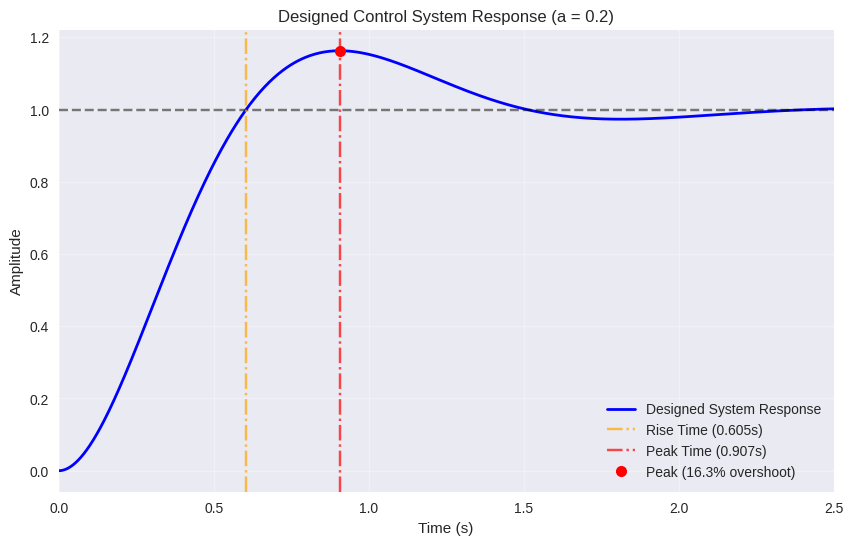

In [17]:
def control_system_design_example():
    """Example: Design control system with specified damping ratio"""
    
    print("Example 1: Control System Design")
    print("Given: G(s) = 16/[s(s + 0.8)], H(s) = 1 + as")
    print("Find: Value of 'a' for ζ = 0.5")
    print("Also find: Rise time, peak time, and maximum overshoot")
    print("-" * 60)
    
    # Given parameters
    desired_zeta = 0.5
    
    # From the characteristic equation: s² + s(0.8 + 16a) + 16 = 0
    # Comparing with standard form: s² + 2ζωₙs + ωₙ² = 0
    wn_squared = 16
    wn = np.sqrt(wn_squared)
    
    # 2ζωₙ = 0.8 + 16a
    # For ζ = 0.5 and ωₙ = 4:
    # 2 * 0.5 * 4 = 0.8 + 16a
    # 4 = 0.8 + 16a
    a = (2 * desired_zeta * wn - 0.8) / 16
    
    print(f"Solution:")
    print(f"ωₙ = {wn} rad/s")
    print(f"Required value of a = {a}")
    
    # Calculate time response parameters
    params = calculate_time_response_parameters(wn, desired_zeta)
    
    print(f"\nTime Response Parameters:")
    print(f"Rise time: Tr = {params['tr']:.3f} s")
    print(f"Peak time: Tp = {params['tp']:.3f} s")
    print(f"Peak overshoot: Mp = {params['mp_percent']:.1f}%")
    
    # Create the designed system
    # T(s) = 16/(s² + 4s + 16)
    sys_designed = ct.tf([16], [1, 4, 16])
    
    # Plot step response
    t = np.linspace(0, 3, 1000)
    t_resp, y_resp = ct.step_response(sys_designed, t)
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_resp, y_resp, 'b-', linewidth=2, label='Designed System Response')
    plt.axhline(y=1, color='k', linestyle='--', alpha=0.5)
    plt.axvline(x=params['tr'], color='orange', linestyle='-.', alpha=0.7, label=f'Rise Time ({params["tr"]:.3f}s)')
    plt.axvline(x=params['tp'], color='r', linestyle='-.', alpha=0.7, label=f'Peak Time ({params["tp"]:.3f}s)')
    plt.plot(params['tp'], 1 + params['mp'], 'ro', markersize=8, label=f'Peak ({params["mp_percent"]:.1f}% overshoot)')
    
    plt.title(f'Designed Control System Response (a = {a})')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xlim(0, 2.5)
    plt.show()

control_system_design_example()

### Example 2: Frequency Response from Time Domain Parameters

Example 2: Frequency Response from Time Domain
Given: Maximum overshoot = 50%, Period of damped oscillations = 0.2 sec
Find: Resonant peak, resonant frequency, and bandwidth
----------------------------------------------------------------------
Solution:
Damping ratio: ζ = 0.215
Damped frequency: ωd = 31.42 rad/s
Natural frequency: ωₙ = 32.17 rad/s

Frequency Response Parameters:
Resonant peak: Mᵣ = 2.38 (7.5 dB)
Resonant frequency: ωᵣ = 30.64 rad/s
Bandwidth: ωb = 48.34 rad/s


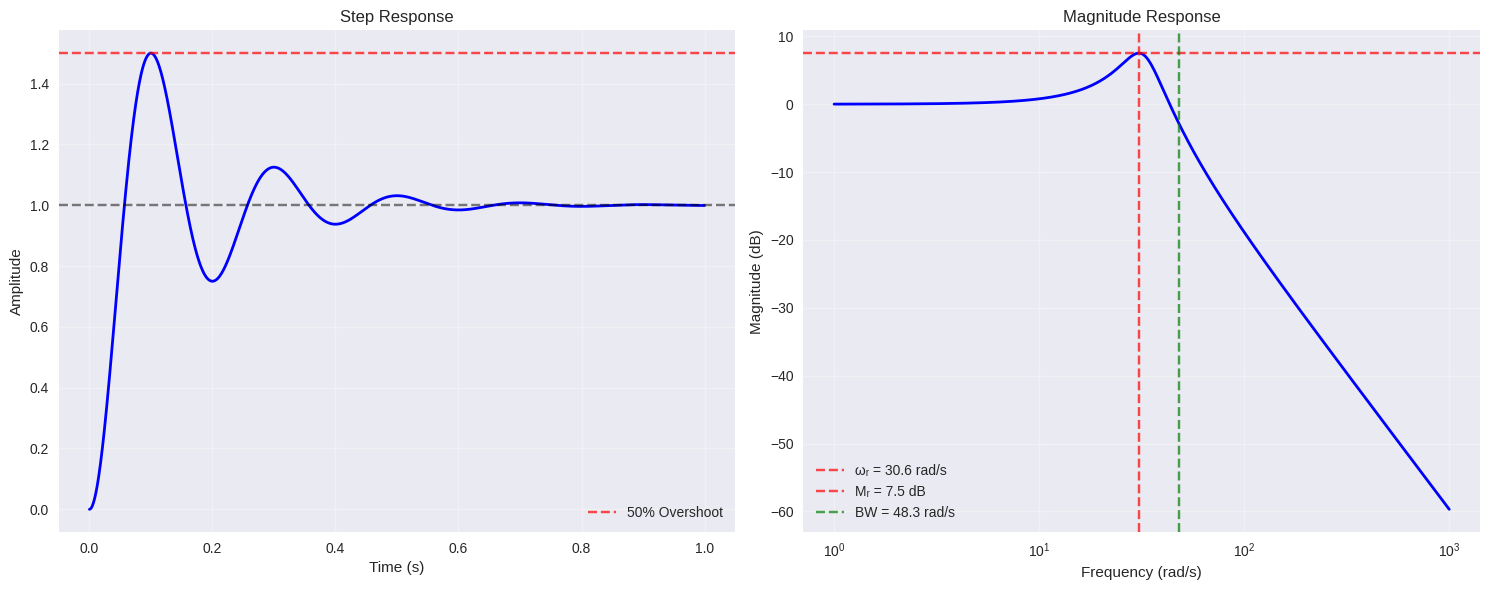

In [18]:
def frequency_from_time_domain_example():
    """Example: Find frequency response parameters from time domain specifications"""
    
    print("Example 2: Frequency Response from Time Domain")
    print("Given: Maximum overshoot = 50%, Period of damped oscillations = 0.2 sec")
    print("Find: Resonant peak, resonant frequency, and bandwidth")
    print("-" * 70)
    
    # Given parameters
    Mp = 0.5  # 50% overshoot
    Td = 0.2  # Period of damped oscillations
    
    # Find damping ratio from overshoot
    # Mp = e^(-ζπ/√(1-ζ²))
    # This is a transcendental equation, solve iteratively
    from scipy.optimize import fsolve
    
    def overshoot_equation(zeta):
        if zeta >= 1:
            return float('inf')
        return np.exp(-zeta * np.pi / np.sqrt(1 - zeta**2)) - Mp
    
    zeta = fsolve(overshoot_equation, 0.3)[0]
    
    # Find natural frequency from period
    # Td = 2π/ωd, where ωd = ωₙ√(1-ζ²)
    wd = 2 * np.pi / Td
    wn = wd / np.sqrt(1 - zeta**2)
    
    print(f"Solution:")
    print(f"Damping ratio: ζ = {zeta:.3f}")
    print(f"Damped frequency: ωd = {wd:.2f} rad/s")
    print(f"Natural frequency: ωₙ = {wn:.2f} rad/s")
    
    # Calculate frequency response parameters
    if zeta < 1/np.sqrt(2):
        wr = wn * np.sqrt(1 - 2*zeta**2)  # Resonance frequency
        Mr = 1 / (2 * zeta * np.sqrt(1 - zeta**2))  # Resonance peak
    else:
        wr = 0
        Mr = 1
    
    # Bandwidth
    wb = wn * np.sqrt((1 - 2*zeta**2) + np.sqrt(4*zeta**4 - 4*zeta**2 + 2))
    
    print(f"\nFrequency Response Parameters:")
    print(f"Resonant peak: Mᵣ = {Mr:.2f} ({20*np.log10(Mr):.1f} dB)")
    print(f"Resonant frequency: ωᵣ = {wr:.2f} rad/s")
    print(f"Bandwidth: ωb = {wb:.2f} rad/s")
    
    # Create system and plot responses
    sys = ct.tf([wn**2], [1, 2*zeta*wn, wn**2])
    
    # Time response
    t = np.linspace(0, 1, 1000)
    t_resp, y_resp = ct.step_response(sys, t)
    
    # Frequency response
    w = np.logspace(0, 3, 1000)
    mag, phase, omega = ct.freqresp(sys, w)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Time response
    ax1.plot(t_resp, y_resp, 'b-', linewidth=2)
    ax1.axhline(y=1, color='k', linestyle='--', alpha=0.5)
    ax1.axhline(y=1.5, color='r', linestyle='--', alpha=0.7, label='50% Overshoot')
    ax1.set_title('Step Response')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Frequency response
    ax2.semilogx(omega, 20 * np.log10(np.abs(mag)), 'b-', linewidth=2)
    if wr > 0:
        ax2.axvline(x=wr, color='r', linestyle='--', alpha=0.7, label=f'ωᵣ = {wr:.1f} rad/s')
        ax2.axhline(y=20*np.log10(Mr), color='r', linestyle='--', alpha=0.7, label=f'Mᵣ = {20*np.log10(Mr):.1f} dB')
    ax2.axvline(x=wb, color='g', linestyle='--', alpha=0.7, label=f'BW = {wb:.1f} rad/s')
    ax2.set_title('Magnitude Response')
    ax2.set_xlabel('Frequency (rad/s)')
    ax2.set_ylabel('Magnitude (dB)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

frequency_from_time_domain_example()

## Summary and Relationships

This notebook demonstrates the key relationships between time and frequency domain parameters in control systems.

/home/spensermillburn/.local/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


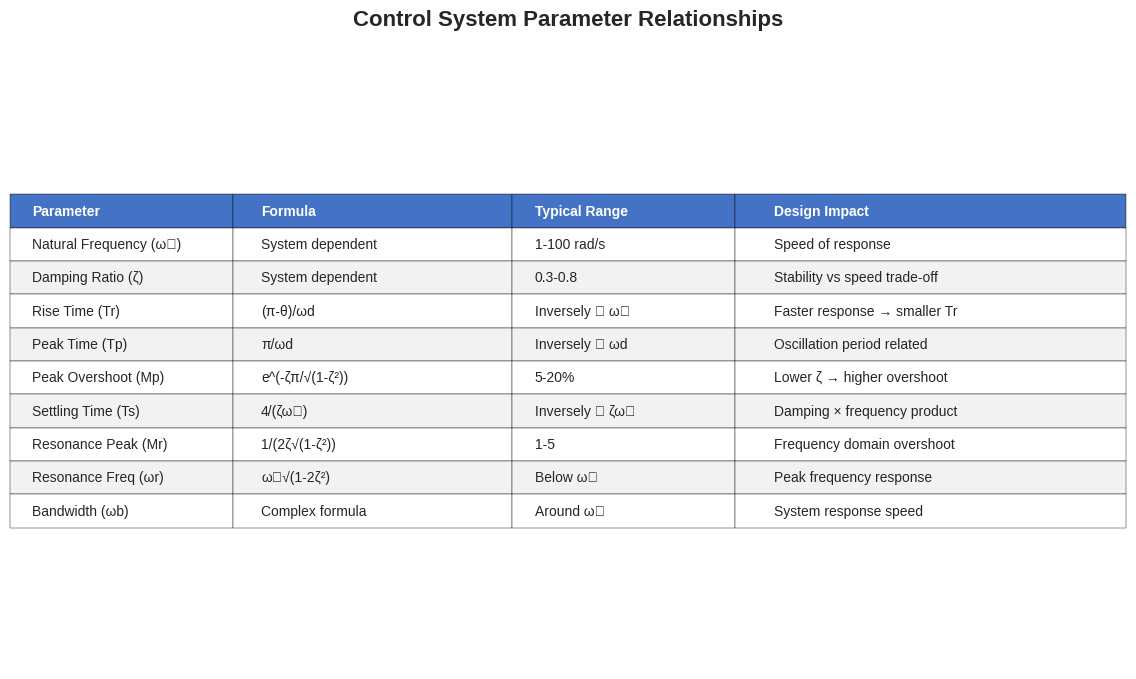


Design Guidelines:
1. For fast response: Increase ωₙ, but expect more overshoot
2. For stable response: Choose ζ = 0.6-0.8
3. For minimal overshoot: Increase ζ, but response becomes slower
4. For good compromise: ζ ≈ 0.707 (critically damped approach)
5. Bandwidth ≈ ωₙ for well-damped systems


In [19]:
def create_parameter_relationship_table():
    """Create a summary table of parameter relationships"""
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.axis('tight')
    ax.axis('off')
    
    # Create comprehensive parameter table
    table_data = [
        ['Parameter', 'Formula', 'Typical Range', 'Design Impact'],
        ['Natural Frequency (ωₙ)', 'System dependent', '1-100 rad/s', 'Speed of response'],
        ['Damping Ratio (ζ)', 'System dependent', '0.3-0.8', 'Stability vs speed trade-off'],
        ['Rise Time (Tr)', '(π-θ)/ωd', 'Inversely ∝ ωₙ', 'Faster response → smaller Tr'],
        ['Peak Time (Tp)', 'π/ωd', 'Inversely ∝ ωd', 'Oscillation period related'],
        ['Peak Overshoot (Mp)', 'e^(-ζπ/√(1-ζ²))', '5-20%', 'Lower ζ → higher overshoot'],
        ['Settling Time (Ts)', '4/(ζωₙ)', 'Inversely ∝ ζωₙ', 'Damping × frequency product'],
        ['Resonance Peak (Mr)', '1/(2ζ√(1-ζ²))', '1-5', 'Frequency domain overshoot'],
        ['Resonance Freq (ωr)', 'ωₙ√(1-2ζ²)', 'Below ωₙ', 'Peak frequency response'],
        ['Bandwidth (ωb)', 'Complex formula', 'Around ωₙ', 'System response speed']
    ]
    
    table = ax.table(cellText=table_data, cellLoc='left', loc='center',
                    colWidths=[0.2, 0.25, 0.2, 0.35])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2.0)
    
    # Style the header row
    for i in range(4):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Alternate row colors
    for i in range(1, len(table_data)):
        for j in range(4):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#F2F2F2')
    
    plt.title('Control System Parameter Relationships', fontsize=16, fontweight='bold', pad=20)
    plt.show()
    
    # Design guidelines
    print("\nDesign Guidelines:")
    print("1. For fast response: Increase ωₙ, but expect more overshoot")
    print("2. For stable response: Choose ζ = 0.6-0.8")
    print("3. For minimal overshoot: Increase ζ, but response becomes slower")
    print("4. For good compromise: ζ ≈ 0.707 (critically damped approach)")
    print("5. Bandwidth ≈ ωₙ for well-damped systems")

create_parameter_relationship_table()

## Conclusion

This notebook has covered the fundamental concepts of control systems time and frequency response analysis:

1. **Test Signals**: Standard inputs for system evaluation
2. **Steady State Error**: System accuracy measurement
3. **System Classification**: Order and type determination
4. **Time Response**: Transient behavior and key parameters
5. **Frequency Response**: Sinusoidal steady-state analysis
6. **Practical Examples**: Real-world design problems

The relationships between time and frequency domain parameters are crucial for control system design, allowing engineers to meet specifications while understanding the inherent trade-offs in system performance.